#  Multi-Class Natural Language Text Sentiment Classifier

**Dataset:** Kaggle — *Twitter US Airline Sentiment* (`crowdflower/twitter-airline-sentiment`)
Classes: `negative` / `neutral` / `positive`

**Pipeline:**
1. Install dependencies
2. Connect to Kaggle & download dataset
3. Preprocess text (stop-word removal + lemmatization)
4. TF-IDF vectorization
5. Train a Logistic Regression classifier
6. Evaluate with Accuracy / Precision / Recall / F1-score + confusion matrix
7. Test on new, unseen sentences

Run the cells **in order**, top to bottom.


## Step 1 — Install dependencies

This installs everything needed: `kagglehub` (to pull the dataset), `nltk` (stop-words + lemmatizer), and scikit-learn / pandas (already present in Colab, but pinned here for safety).

In [1]:
!pip install -q kagglehub nltk scikit-learn pandas numpy

## Step 2 — Set up your Kaggle API credentials

You need a free Kaggle account + API token so `kagglehub` can download the dataset.

1. Go to **https://www.kaggle.com/settings** → **API** → **Create New Token**.
   This downloads a file called `kaggle.json`.
2. Run the cell below, then click **"Choose Files"** and upload that `kaggle.json` when prompted.

*(This only uploads the token to this temporary Colab session — it is not saved anywhere permanent.)*

In [3]:
import os

from google.colab import files

print("Please upload your kaggle.json file (from https://www.kaggle.com/settings -> API -> Create New Token)")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
for fname in uploaded.keys():
    os.rename(fname, "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle credentials configured.")

Please upload your kaggle.json file (from https://www.kaggle.com/settings -> API -> Create New Token)


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


## Step 3 — Imports & one-time NLTK downloads

In [4]:
import re
import string
import warnings

import kagglehub
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt", "punkt_tab"]:
    try:
        nltk.data.find(pkg)
    except LookupError:
        nltk.download(pkg, quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
print("Setup complete.")

Setup complete.


## Step 4 — Download the Kaggle dataset

Downloads (and caches) the *Twitter US Airline Sentiment* dataset and loads it into a DataFrame with just two columns: `text` and `label`.

In [5]:
KAGGLE_DATASET_SLUG = "crowdflower/twitter-airline-sentiment"

dataset_path = kagglehub.dataset_download(KAGGLE_DATASET_SLUG)
print("Dataset downloaded to:", dataset_path)

csv_file = None
for fname in os.listdir(dataset_path):
    if fname.lower().endswith(".csv"):
        csv_file = os.path.join(dataset_path, fname)
        break

if csv_file is None:
    raise FileNotFoundError(f"No CSV found in downloaded Kaggle dataset at {dataset_path}")

raw = pd.read_csv(csv_file)
print("Raw columns:", list(raw.columns))

df = raw[["text", "airline_sentiment"]].rename(columns={"airline_sentiment": "label"})
df = df.dropna(subset=["text", "label"]).reset_index(drop=True)

print(f"\nTotal samples: {len(df)}")
print("Class distribution:")
print(df["label"].value_counts())
df.head()

Using Colab cache for faster access to the 'twitter-airline-sentiment' dataset.
Dataset downloaded to: /kaggle/input/twitter-airline-sentiment
Raw columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Total samples: 14640
Class distribution:
label
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


,text,label
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


## Step 5 — Text preprocessing

Lowercase → remove URLs/numbers/punctuation → tokenize → remove stop-words → lemmatize.

In [6]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"@\w+", " ", text)                     # mentions (tweets)
    text = re.sub(r"\d+", " ", text)                       # numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # punctuation

    tokens = word_tokenize(text)
    cleaned_tokens = [
        LEMMATIZER.lemmatize(tok)
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 1
    ]
    return " ".join(cleaned_tokens)


print("Preprocessing text (stop-word removal + lemmatization)...")
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text", "label"]].head(10)

Preprocessing text (stop-word removal + lemmatization)...


,text,clean_text,label
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky,positive
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip,neutral
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,negative
4,@VirginAmerica and it's a really big bad thing...,really big bad thing,negative
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay flight seat didnt playing ...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly vx ear worm go away,positive
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men without ha...,neutral
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well didnt…but,positive
9,"@VirginAmerica it was amazing, and arrived an ...",amazing arrived hour early youre good,positive


## Step 5.5 — Exploratory Data Analysis (EDA)

### Text Length Analysis

Let's analyze the distribution of the original and cleaned text lengths.

In [13]:
# Add columns for text length
df['text_length'] = df['text'].apply(len)
df['clean_text_length'] = df['clean_text'].apply(len)

print("Original Text Length Description:")
display(df['text_length'].describe())

print("\nCleaned Text Length Description:")
display(df['clean_text_length'].describe())

Original Text Length Description:


,text_length
count,14640.000000
mean,103.822063
std,36.277339
min,12.000000
25%,77.000000
50%,114.000000
75%,136.000000
max,186.000000



Cleaned Text Length Description:


,clean_text_length
count,14640.000000
mean,56.968443
std,25.732543
min,0.000000
25%,37.000000
50%,60.000000
75%,77.000000
max,133.000000


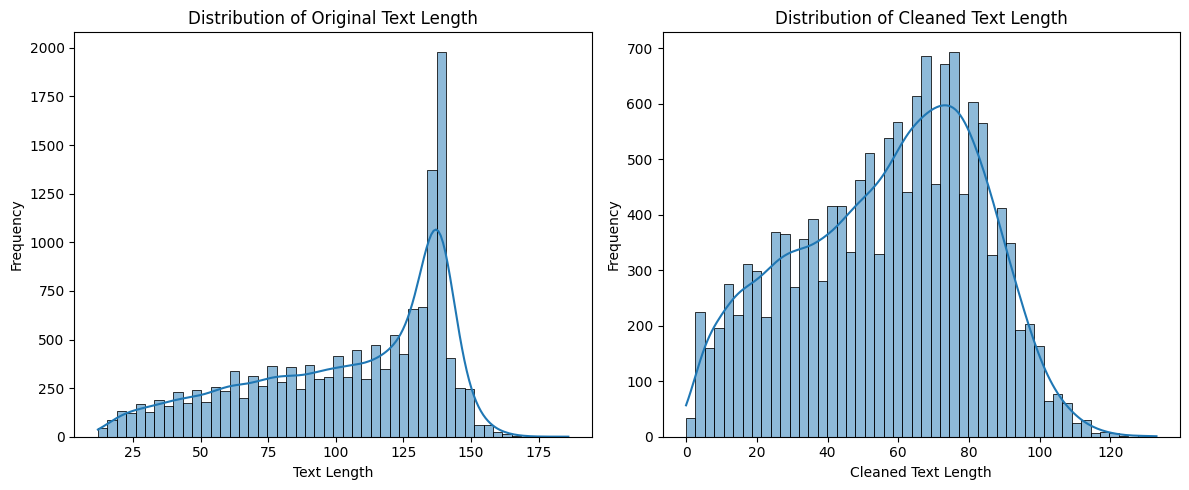

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting text length distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Original Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['clean_text_length'], bins=50, kde=True)
plt.title('Distribution of Cleaned Text Length')
plt.xlabel('Cleaned Text Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Sentiment Distribution

Visualize the distribution of sentiment labels in the dataset.

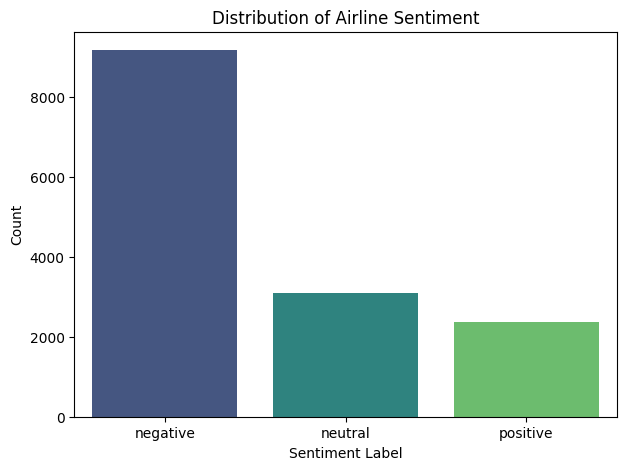

In [15]:
# Plotting sentiment distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, palette='viridis', order=df['label'].value_counts().index)
plt.title('Distribution of Airline Sentiment')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

### Word Clouds

Generate word clouds to visualize the most frequent words in the cleaned text for each sentiment category.

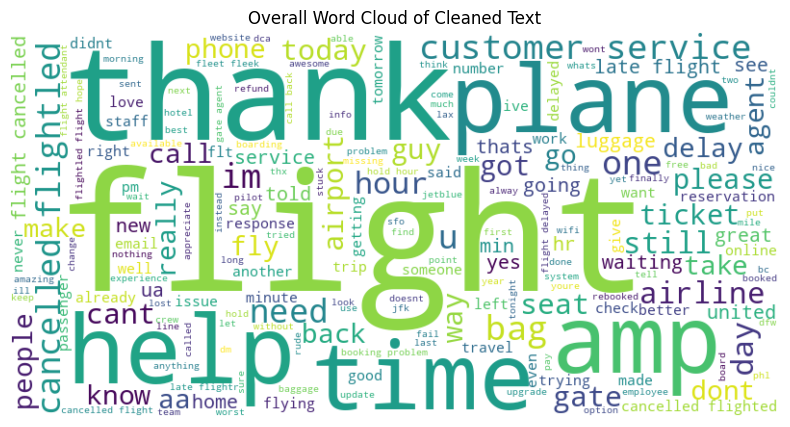

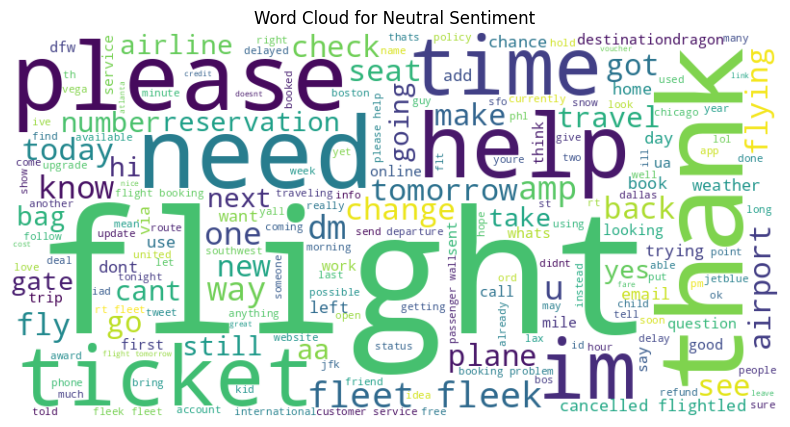

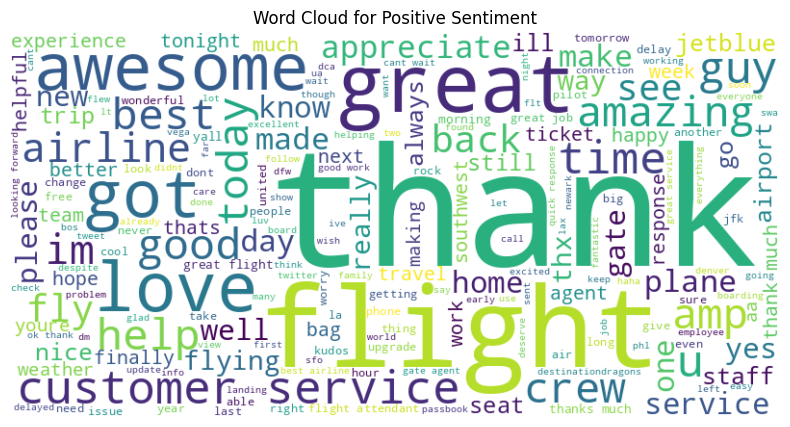

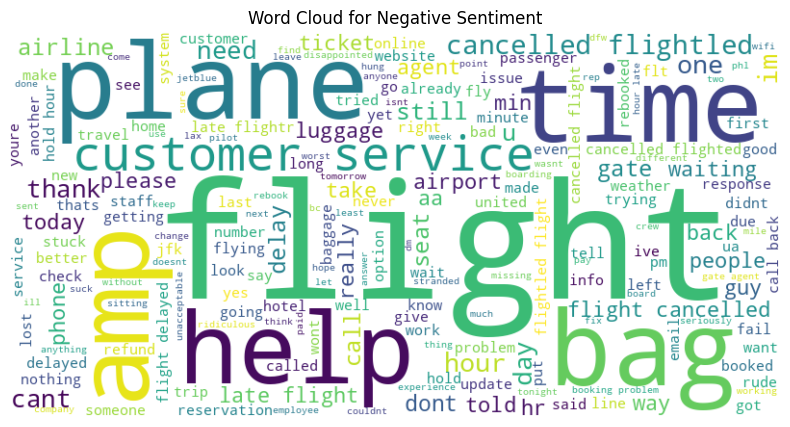

In [16]:
from wordcloud import WordCloud

def generate_wordcloud(text_data, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Combine all cleaned text for overall word cloud
all_cleaned_text = ' '.join(df['clean_text'])
generate_wordcloud(all_cleaned_text, 'Overall Word Cloud of Cleaned Text')

# Word clouds for each sentiment
for sentiment in df['label'].unique():
    sentiment_text = ' '.join(df[df['label'] == sentiment]['clean_text'])
    generate_wordcloud(sentiment_text, f'Word Cloud for {sentiment.capitalize()} Sentiment')

### Top N-grams by Sentiment

Let's extract and visualize the most frequent unigrams and bigrams for each sentiment category.


Top Unigrams for Neutral Sentiment:


,Unigram,Frequency
0,flight,127.571217
1,get,52.757570
2,dm,51.255383
3,fleek,50.777864
4,thanks,49.890652
5,fleet,49.772251
6,please,49.009680
7,help,41.644590
8,need,41.180115
9,thank,33.116722



Top Bigrams for Neutral Sentiment:


,Bigram,Frequency
0,fleet fleek,56.635510
1,rt fleet,17.352073
2,cancelled flightled,12.302681
3,booking problem,8.081917
4,follow dm,8.067241
5,sent dm,7.162103
6,flight tomorrow,7.142955
7,please help,7.067178
8,flight booking,6.745330
9,passenger wall,6.692692


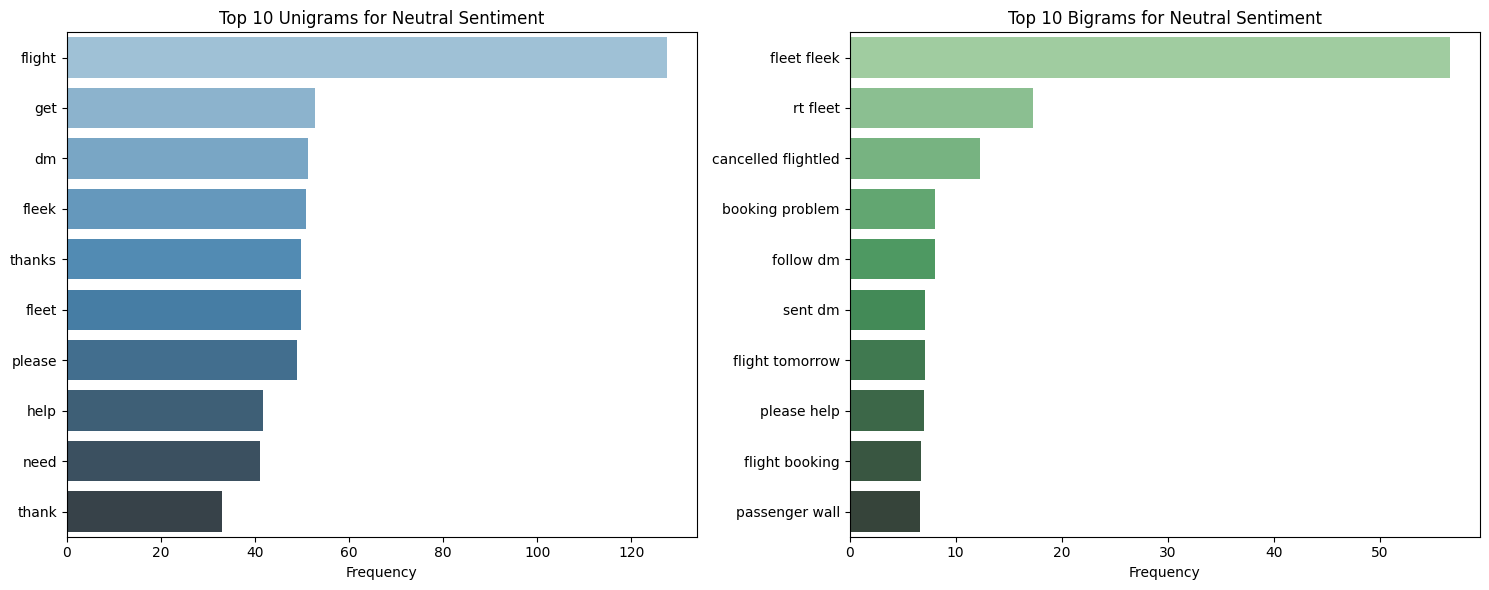


Top Unigrams for Positive Sentiment:


,Unigram,Frequency
0,thanks,163.465445
1,thank,151.908512
2,flight,71.725998
3,great,59.845971
4,much,38.608545
5,service,36.044773
6,love,35.139869
7,guy,34.425311
8,awesome,33.503262
9,best,31.330573



Top Bigrams for Positive Sentiment:


,Bigram,Frequency
0,customer service,19.003904
1,thank much,16.138764
2,thanks much,13.866785
3,great flight,8.718001
4,great thank,7.858235
5,thanks help,7.798957
6,awesome thanks,7.393543
7,flight attendant,7.387714
8,cant wait,6.875018
9,fleet fleek,6.816278


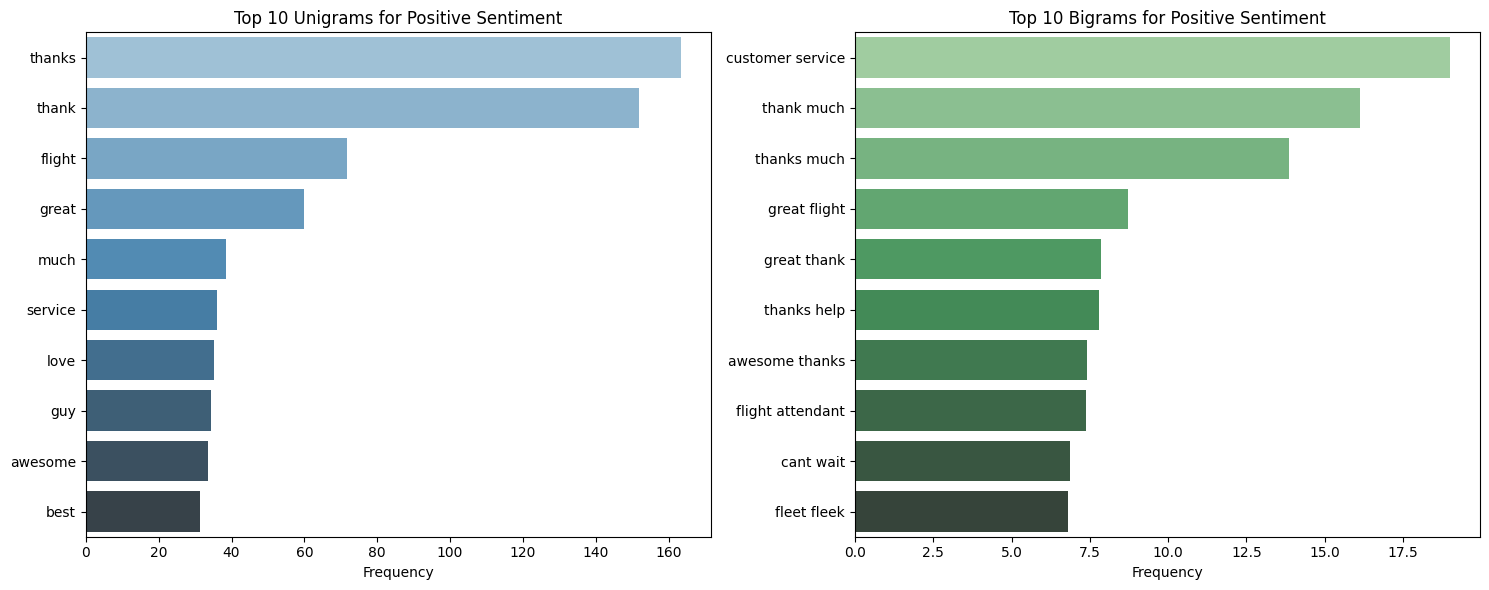


Top Unigrams for Negative Sentiment:


,Unigram,Frequency
0,flight,402.630033
1,hour,206.232463
2,get,181.300408
3,cancelled,171.404273
4,customer,151.220895
5,service,150.905354
6,hold,141.195750
7,time,140.734714
8,help,131.292286
9,bag,128.454004



Top Bigrams for Negative Sentiment:


,Bigram,Frequency
0,customer service,75.913001
1,cancelled flightled,71.140306
2,flight cancelled,42.354757
3,late flight,41.018108
4,cancelled flighted,37.388130
5,hold hour,31.274505
6,flight delayed,27.477164
7,cancelled flight,26.359783
8,late flightr,25.836786
9,flightled flight,25.823635


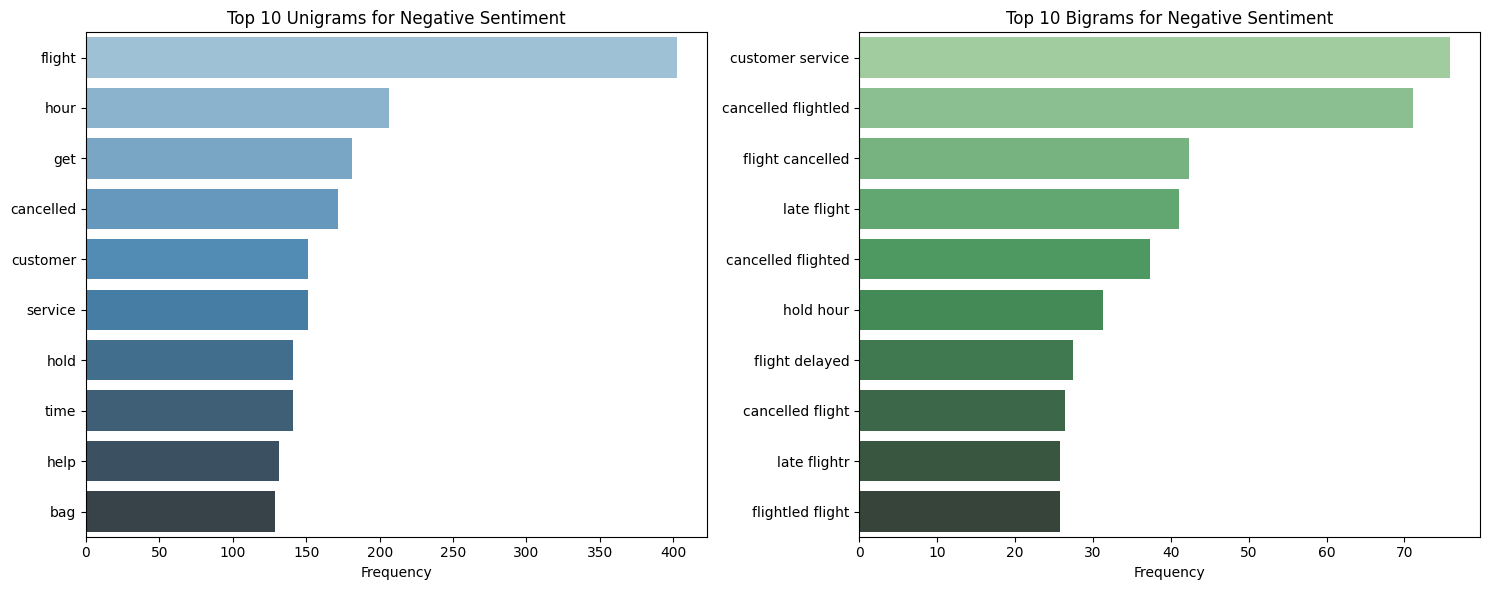

In [17]:
from collections import Counter
from itertools import chain

def get_top_ngrams(corpus, n=None, num_ngrams=10):
    vec = TfidfVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:num_ngrams]

# Get top unigrams and bigrams for each sentiment
sentiments = df['label'].unique()
for sentiment in sentiments:
    sentiment_df = df[df['label'] == sentiment]
    corpus = sentiment_df['clean_text']

    print(f"\nTop Unigrams for {sentiment.capitalize()} Sentiment:")
    top_unigrams = get_top_ngrams(corpus, n=1)
    display(pd.DataFrame(top_unigrams, columns=['Unigram', 'Frequency']))

    print(f"\nTop Bigrams for {sentiment.capitalize()} Sentiment:")
    top_bigrams = get_top_ngrams(corpus, n=2)
    display(pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency']))

    # Plotting top N-grams
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Unigrams
    if top_unigrams:
        unigrams_df = pd.DataFrame(top_unigrams, columns=['Unigram', 'Frequency'])
        sns.barplot(x='Frequency', y='Unigram', data=unigrams_df, ax=axes[0], palette='Blues_d')
        axes[0].set_title(f'Top 10 Unigrams for {sentiment.capitalize()} Sentiment')
        axes[0].set_xlabel('Frequency')
        axes[0].set_ylabel('')
    else:
        axes[0].set_title(f'No Unigrams for {sentiment.capitalize()} Sentiment')

    # Bigrams
    if top_bigrams:
        bigrams_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])
        sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, ax=axes[1], palette='Greens_d')
        axes[1].set_title(f'Top 10 Bigrams for {sentiment.capitalize()} Sentiment')
        axes[1].set_xlabel('Frequency')
        axes[1].set_ylabel('')
    else:
        axes[1].set_title(f'No Bigrams for {sentiment.capitalize()} Sentiment')

    plt.tight_layout()
    plt.show()

## Step 6 — Train / test split + TF-IDF vectorization

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.25,
    random_state=42,
    stratify=df["label"],
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape :", X_test_tfidf.shape)

Train shape: (10980, 5000)
Test shape : (3660, 5000)


## Step 7 — Train the classifier (Logistic Regression)

In [19]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_tfidf, y_train)
print("Model trained.")

Model trained.


## Step 8 — Evaluate: Accuracy, Precision, Recall, F1-score, Confusion Matrix

In [20]:
y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy           : {acc:.4f}")
print(f"Precision (macro)  : {precision_macro:.4f}")
print(f"Recall (macro)     : {recall_macro:.4f}")
print(f"F1-score (macro)   : {f1_macro:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}\n")

print("Full classification report:\n")
print(classification_report(y_test, y_pred, digits=4))

EVALUATION RESULTS
Accuracy           : 0.7585
Precision (macro)  : 0.7022
Recall (macro)     : 0.7354
F1-score (macro)   : 0.7140
F1-score (weighted): 0.7666

Full classification report:

              precision    recall  f1-score   support

    negative     0.8952    0.7895    0.8390      2294
     neutral     0.5348    0.6942    0.6042       775
    positive     0.6767    0.7225    0.6989       591

    accuracy                         0.7585      3660
   macro avg     0.7022    0.7354    0.7140      3660
weighted avg     0.7836    0.7585    0.7666      3660



In [10]:
labels_sorted = sorted(df["label"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

print("Confusion Matrix (rows = actual, columns = predicted)")
print("Labels order:", labels_sorted)
print(cm)

Confusion Matrix (rows = actual, columns = predicted)
Labels order: ['negative', 'neutral', 'positive']
[[1811  365  118]
 [ 151  538   86]
 [  61  103  427]]


### Optional — visualize the confusion matrix as a heatmap

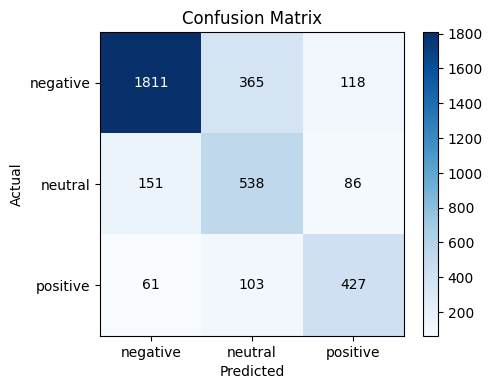

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_sorted)))
ax.set_yticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted)
ax.set_yticklabels(labels_sorted)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

## Step 8.5 — Learning Curve

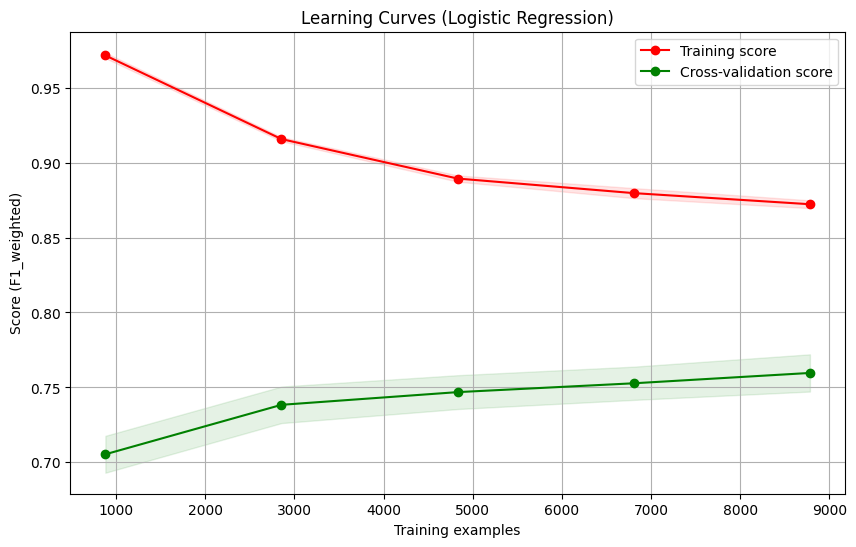

In [22]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None,
                        cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5),
                        scoring='accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        Target relative to X for classification or regression; None for
        unsupervised learning.

    axes : array-like of shape (3,), optional
        Axes to use for plotting the curves. Defaults to a single axes.

    ylim : tuple, shape (2,), optional
        Defines limits for the y-axis.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - An object to be used as a cross-validation generator.
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if `y` is binary or multiclass, `StratifiedKFold` is used.
        If the estimator is not a classifier or if `y` is neither binary nor multiclass,
        `KFold` is used. (Default is None)

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel. `None` means 1 unless in a
        `joblib.parallel_backend` context. `-1` means using all processors.

    train_sizes : array-like, shape (n_patches,),
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.

    scoring : string or callable, optional (default='accuracy')
        A string (see model evaluation documentation) or a scorer callable object / function.
        If None, the estimator's default scorer is used.
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 6))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel(f"Score ({scoring.capitalize()})")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, scoring=scoring,
                       return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes.legend(loc="best")

    return plt

# Generate and plot the learning curve
plt_learning_curve = plot_learning_curve(model, "Learning Curves (Logistic Regression)",
                           X_train_tfidf, y_train, cv=5, n_jobs=-1,
                           scoring='f1_weighted') # Using f1_weighted due to class imbalance

plt_learning_curve.show()

## Step 9 — Try it on new, unseen sentences

In [23]:
sample_inputs = [
    "This is honestly the best thing I have ever bought.",
    "The service was awful and I want my money back.",
    "The office is located on the third floor near the elevator.",
    "Flight was delayed by three hours with zero updates from staff.",
    "Thank you for the smooth check-in experience today!",
]

cleaned_samples = [clean_text(s) for s in sample_inputs]
sample_tfidf = vectorizer.transform(cleaned_samples)
sample_preds = model.predict(sample_tfidf)

print("Sample predictions on new text:\n")
for text, pred in zip(sample_inputs, sample_preds):
    print(f"  [{pred:>8}]  {text}")

Sample predictions on new text:

  [positive]  This is honestly the best thing I have ever bought.
  [negative]  The service was awful and I want my money back.
  [ neutral]  The office is located on the third floor near the elevator.
  [negative]  Flight was delayed by three hours with zero updates from staff.
  [positive]  Thank you for the smooth check-in experience today!


## Step 9.5 — Evaluate on User-Provided Test Dataset

In [25]:
## Step 10 — Test the trained model on a new held-out dataset
from google.colab import files
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)

print("Please upload your test CSV (must have 'text' and 'label' columns)")
uploaded = files.upload()
test_csv_name = list(uploaded.keys())[0]

test_df = pd.read_csv(test_csv_name)
test_df = test_df.dropna(subset=["text"])
has_labels = "label" in test_df.columns

test_df["clean_text"] = test_df["text"].apply(clean_text)
X_test_new = vectorizer.transform(test_df["clean_text"])
test_df["predicted_label"] = model.predict(X_test_new)

if has_labels:
    y_true = test_df["label"]
    y_pred = test_df["predicted_label"]

    print("=" * 60)
    print("TEST RESULTS ON NEW DATA")
    print("=" * 60)
    print(f"Accuracy           : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision (macro)  : {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall (macro)     : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro)   : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}\n")

    print(classification_report(y_true, y_pred, digits=4))

    labels_sorted = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
    print("Confusion Matrix (rows = actual, columns = predicted)")
    print("Labels order:", labels_sorted)
    print(cm)

    mistakes = test_df[y_true != y_pred][["text", "label", "predicted_label"]]
    print(f"\nMisclassified: {len(mistakes)} / {len(test_df)}")
    display(mistakes.head(15))
else:
    print("No 'label' column found — showing predictions only.\n")
    display(test_df[["text", "predicted_label"]].head(20))

test_df.drop(columns=["clean_text"]).to_csv("predictions.csv", index=False)
files.download("predictions.csv")

Please upload your test CSV (must have 'text' and 'label' columns)


Saving test_dataset.csv to test_dataset (1).csv
TEST RESULTS ON NEW DATA
Accuracy           : 0.6667
Precision (macro)  : 0.6846
Recall (macro)     : 0.6667
F1-score (macro)   : 0.6636
F1-score (weighted): 0.6636

              precision    recall  f1-score   support

    negative     0.5714    0.8000    0.6667        15
     neutral     0.6364    0.4667    0.5385        15
    positive     0.8462    0.7333    0.7857        15

    accuracy                         0.6667        45
   macro avg     0.6846    0.6667    0.6636        45
weighted avg     0.6846    0.6667    0.6636        45

Confusion Matrix (rows = actual, columns = predicted)
Labels order: ['negative', 'neutral', 'positive']
[[12  1  2]
 [ 8  7  0]
 [ 1  3 11]]

Misclassified: 15 / 45


,text,label,predicted_label
8,"Dinner was absolutely delicious, the chef outd...",positive,neutral
9,"The repair technician was punctual, polite, an...",positive,neutral
11,"I felt so relaxed after the spa treatment, hig...",positive,neutral
12,The keynote speaker was engaging and full of p...,positive,negative
16,This washing machine broke down after only thr...,negative,neutral
26,The software update wiped out all my saved set...,negative,positive
28,The contractor left the job unfinished and sto...,negative,positive
31,The office relocated to the third floor of the...,neutral,negative
33,The conference room can seat up to twenty people.,neutral,negative
34,The bus route was changed to include two addit...,neutral,negative


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>